# Exercise 17 - ObsPy - Intro

## 1. UTCDateTime Exercises


**Exercise 1.1:**

Calculate the time since the Tohoku main shock. Please state the time once in `days` and once in `seconds`.

Main shock: `2011, 3, 11, 5, 46, 23.2`.

In [1]:
from obspy import UTCDateTime

tohoku_time = UTCDateTime(2011, 3, 11, 5, 46, 23.2)

now = UTCDateTime()

time_diff_seconds = now - tohoku_time

time_diff_days = time_diff_seconds / (24 * 60 * 60)

print(f"Time since Tohoku: {time_diff_days:.2f} days")
print(f"Time since Tohoku: {time_diff_seconds:.2f} seconds")

Time since Tohoku: 5557.18 days
Time since Tohoku: 480140420.83 seconds


**Exercise 1.2:**

Make a list of 10 UTCDateTime objects, starting today at 10:00 with a spacing of 90 minutes.

In [2]:
from obspy import UTCDateTime

start_time = UTCDateTime("2026-05-28T10:00:00")

spacing_seconds = 90 * 60

time_list = []

for i in range(10):
    
    new_time = start_time + (i * spacing_seconds)
    time_list.append(new_time)


for t in time_list:
    print(t)

2026-05-28T10:00:00.000000Z
2026-05-28T11:30:00.000000Z
2026-05-28T13:00:00.000000Z
2026-05-28T14:30:00.000000Z
2026-05-28T16:00:00.000000Z
2026-05-28T17:30:00.000000Z
2026-05-28T19:00:00.000000Z
2026-05-28T20:30:00.000000Z
2026-05-28T22:00:00.000000Z
2026-05-28T23:30:00.000000Z


**Exercise 1.3:**

Below is a list of strings with origin times of magnitude 8+ earthquakes since 2000 (fetched from IRIS).

Assemble a list of interevent times (time between each consecutive event) in days.

Use matplotlib to display a histogram.

In [2]:
EQtimes = ["2001-06-23T20:33:09",
         "2003-09-25T19:50:07",
         "2004-12-23T14:59:00",
         "2004-12-26T00:58:52",
         "2005-03-28T16:09:35",
         "2006-06-01T18:57:02",
         "2006-06-05T00:50:31",
         "2006-11-15T11:14:14",
         "2007-01-13T04:23:23",
         "2007-04-01T20:39:56",
         "2007-08-15T23:40:58",
         "2007-09-12T11:10:26",
         "2009-09-29T17:48:11",
         "2010-02-27T06:34:13",
         "2011-03-11T05:46:23",
         "2012-04-11T08:38:36",
         "2012-04-11T10:43:10",
         "2013-05-24T05:44:48"]

In [4]:
!pip install obspy

   ---------------------------------------- 0.0/14.8 MB ? eta -:--:--
   - -------------------------------------- 0.5/14.8 MB 2.5 MB/s eta 0:00:06
   --- ------------------------------------ 1.3/14.8 MB 3.5 MB/s eta 0:00:04
   ------ --------------------------------- 2.4/14.8 MB 4.1 MB/s eta 0:00:04
   --------- ------------------------------ 3.4/14.8 MB 4.3 MB/s eta 0:00:03
   --------- ------------------------------ 3.4/14.8 MB 4.3 MB/s eta 0:00:03
   ------------ --------------------------- 4.7/14.8 MB 4.0 MB/s eta 0:00:03
   ----------------- ---------------------- 6.6/14.8 MB 4.5 MB/s eta 0:00:02
   ------------------- -------------------- 7.3/14.8 MB 4.6 MB/s eta 0:00:02
   ---------------------- ----------------- 8.4/14.8 MB 4.4 MB/s eta 0:00:02
   ------------------------- -------------- 9.4/14.8 MB 4.5 MB/s eta 0:00:02
   ---------------------------- ----------- 10.5/14.8 MB 4.5 MB/s eta 0:00:01
   ------------------------------ --------- 11.3/14.8 MB 4.6 MB/s eta 0:00:01
   -

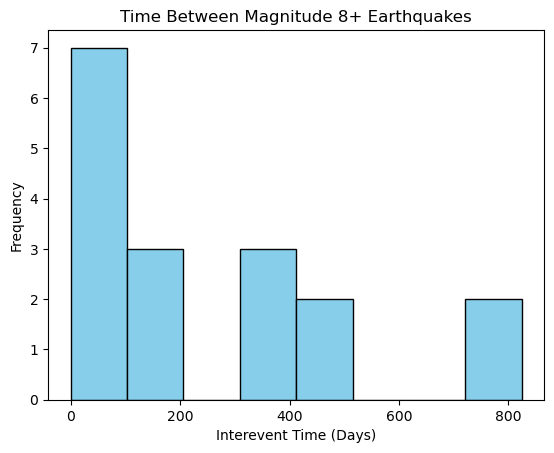

In [5]:
from obspy import UTCDateTime
import matplotlib.pyplot as plt

EQLines = [
    "2001-06-23T20:33:09",
    "2003-09-25T19:50:07",
    "2004-12-23T14:59:00",
    "2004-12-26T00:58:52",
    "2005-03-28T16:09:35",
    "2006-06-01T18:57:02",
    "2006-06-05T00:50:31",
    "2006-11-15T11:14:14",
    "2007-01-13T04:23:23",
    "2007-04-01T20:39:56",
    "2007-08-15T23:40:58",
    "2007-09-12T11:10:26",
    "2009-09-29T17:48:11",
    "2010-02-27T06:34:13",
    "2011-03-11T05:46:23",
    "2012-04-11T08:38:36",
    "2012-04-11T10:43:10",
    "2013-05-24T05:44:48"
]


eq_times = []
for date_str in EQLines:
    eq_times.append(UTCDateTime(date_str))


interevent_days = []

for i in range(len(eq_times) - 1):
    
    diff_seconds = eq_times[i + 1] - eq_times[i]
    
    
    diff_days = diff_seconds / (24 * 60 * 60)
    
    
    interevent_days.append(diff_days)


plt.hist(interevent_days, bins=8, edgecolor='black', color='skyblue')


plt.xlabel('Interevent Time (Days)')
plt.ylabel('Frequency')
plt.title('Time Between Magnitude 8+ Earthquakes')


plt.show()

## 2. FDSN Client Exercise

**Exercise 2.1:**

Use the FDSN client to assemble a waveform dataset for on event.

- search for a large earthquake (e.g. by depth or in a region of your choice, use option **`limit=5`** to keep network traffic down)

In [1]:
from obspy.clients.fdsn import Client
from obspy import UTCDateTime

event_client = Client("USGS")

station_client = Client("EARTHSCOPE")

t1 = UTCDateTime("2023-01-01")
t2 = UTCDateTime("2024-01-01")

catalog = event_client.get_events(starttime=t1, endtime=t2, minmagnitude=7.5, limit=5)
print(catalog)

5 Event(s) in Catalog:
2023-12-02T14:37:04.454000Z |  +8.527, +126.416 | 7.6  mww | manual
2023-05-19T02:57:03.172000Z | -23.206, +170.742 | 7.7  mww | manual
2023-05-10T16:02:00.334000Z | -15.628, -174.493 | 7.6  mww | manual
2023-02-06T10:24:48.811000Z | +38.011,  +37.196 | 7.5  mww | manual
2023-02-06T01:17:34.342000Z | +37.226,  +37.014 | 7.8  mww | manual


**Exercise 2.2:**

Pick an `Event` from the `Catalog` obtained in **Exercise 2.1** and search for `Stations` associated with the event.

Stations should:
- be available at the time of the event
- have a vertical 1 Hz stream ("LHZ", to not overpower our network..)
- be in a narrow angular distance around the event (e.g. 90-91 degrees)
- adjust your search so that only a small number of stations (e.g. 3-6) match your search criteria

**Hint**: Take a look at `event.origins` and at [Obspy - Origin](https://docs.obspy.org/packages/autogen/obspy.core.event.origin.Origin.html) to obtain search parameter.

In [2]:

event = catalog[0]
origin = event.origins[0]

event_time = origin.time
event_lat = origin.latitude
event_lon = origin.longitude

print(f"Event Time: {event_time}, Lat: {event_lat}, Lon: {event_lon}")

inventory = station_client.get_stations(
    starttime=event_time,
    endtime=event_time + 3600, 
    latitude=event_lat,
    longitude=event_lon,
    minradius=90.0, 
    maxradius=91.0, 
    channel="LHZ",  
    level="channel" 
)

print(inventory)

Event Time: 2023-12-02T14:37:04.454000Z, Lat: 8.5266, Lon: 126.4161
Inventory created at 2026-07-10T14:02:51.600000Z
	Created by: EarthScope WEB SERVICE: fdsnws-station | version: 1.1.56
		    https://service.earthscope.org/fdsnws/station/1/query?starttime=202...
	Sending institution: EarthScope (EarthScope)
	Contains:
		Networks (3):
			GE, PL, TZ
		Stations (4):
			GE.SLIT (LEGMA/GEOFON Station Slitere, Latvia)
			GE.SUW (GEOFON Station Suwalki, Poland)
			PL.SUW (PLSN/GEOFON Station Suwalki, Poland)
			TZ.OLDO (Ol Doinyo Lengai, Tanzania; colocated with TZVOLCANO)
		Channels (4):
			GE.SLIT..LHZ, GE.SUW..LHZ, PL.SUW..LHZ, TZ.OLDO..LHZ


**Exercise 2.3:**

- for each of these stations download waveform data of the event, e.g. a couple of minutes before to half an hour after the event
- put all data together in one stream (put the `get_waveforms()` call in a try/except/pass block to silently skip stations that actually have no data available)
- print stream info
- plot the raw data (all Traces)

1 Trace(s) in Stream:
PL.SUW..LHZ | 2023-12-02T14:35:05.120000Z - 2023-12-02T15:07:04.120000Z | 1.0 Hz, 1920 samples


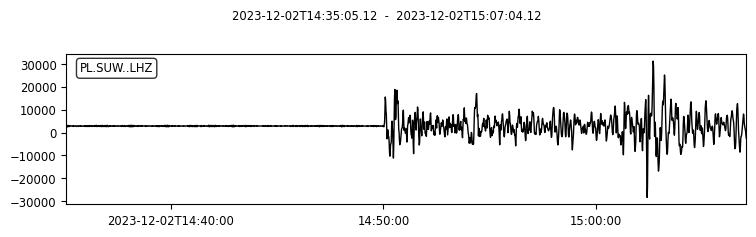

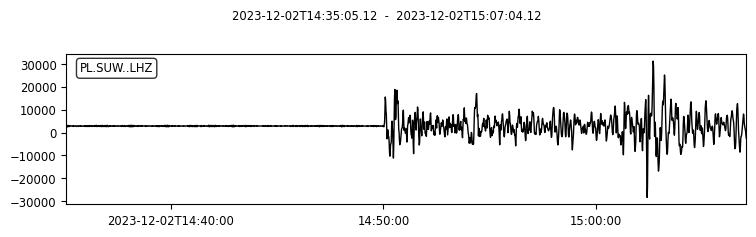

In [3]:
from obspy import Stream

st = Stream()

start_wave = event_time - 120
end_wave = event_time + 1800

for network in inventory:
    for station in network:
        try:
            
            waveforms = station_client.get_waveforms(
                network=network.code,
                station=station.code,
                location="*", 
                channel="LHZ",
                starttime=start_wave,
                endtime=end_wave
            )
            
            st += waveforms
        except Exception:
            
            pass


print(st)


st.plot()